In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.optimize import curve_fit

In [2]:
# ===============================
# 1. Datos de calibración
# ===============================

# Distancias de referencia (m) — orden: lejos (250 mm) → cerca (0 mm)
distance = [0.250, 0.240, 0.230, 0.220, 0.210,
            0.200, 0.190, 0.180, 0.170, 0.160, 0.150, 0.140, 0.130, 0.120, 0.110,
            0.100, 0.090, 0.080, 0.070, 0.060, 0.050, 0.040, 0.030, 0.020, 0.010, 0.000]

# Cada entry contiene los valores raw del ADC para los 4 sensores.
# Orden de los arrays: lejos (250 mm) → cerca (0 mm), 26 valores.
DATASETS = [
    {
        'label': 'ZoroBot A',
        'front_left':  [112, 125, 140, 159, 179, 204, 234, 263, 301, 348, 396, 445, 504, 578, 664, 773, 900, 1072, 1281, 1538, 1897, 2293, 2809, 3368, 3706, 3776],
        'front_right': [121, 131, 146, 157, 181, 206, 234, 268, 306, 337, 377, 429, 490, 559, 642, 747, 877, 1033, 1231, 1487, 1802, 2213, 2712, 3323, 3733, 3793],
        'side_left':   [116, 123, 132, 141, 152, 164, 176, 190, 205, 225, 246, 273, 304, 339, 382, 434, 494, 567, 662, 781, 934, 1137, 1400, 1786, 2296, 2951],
        'side_right':  [74, 84, 90, 98, 106, 117, 128, 141, 158, 174, 191, 218, 248, 284, 325, 369, 423, 489, 576, 682, 816, 1003, 1247, 1543, 1954, 2511],
    },
    {
        'label': 'ZoroBot B',
        'front_left':  [106, 120, 135, 152, 165, 184, 207, 232, 262, 296, 333, 376, 428, 493, 571, 663, 778, 904, 1078, 1283, 1531, 1876, 2297, 2808, 3296, 3516],
        'front_right': [105, 118, 127, 142, 156, 170, 192, 215, 245, 270, 315, 350, 400, 465, 530, 625, 735, 870, 1050, 1240, 1530, 1865, 2220, 2735, 3200, 3460],
        'side_left':   [47, 52, 58, 64, 70, 78, 88, 98, 110, 123, 138, 160, 190, 220, 265, 312, 380, 452, 543, 650, 800, 1000, 1270, 1620, 2120, 2725],
        'side_right':  [93, 97, 99, 107, 115, 125, 132, 140, 156, 178, 190, 212, 238, 278, 306, 355, 411, 470, 537, 656, 782, 928, 1177, 1427, 1781, 2163],
    },
    {
        'label': 'ZoroBot C',
        'front_left':  [67, 73, 81, 101, 116, 139, 164, 187, 216, 248, 288, 325, 379, 438, 508, 597, 709, 840, 1018, 1224, 1488, 1823, 2257, 2819, 3397, 3735],
        'front_right': [104, 110, 131, 145, 155, 179, 202, 228, 265, 303, 337, 390, 442, 509, 586, 670, 803, 937, 1119, 1329, 1605, 1920, 2347, 2857, 3411, 3610],
        'side_left':   [49, 53, 58, 63, 66, 72, 84, 88, 99, 109, 116, 131, 156, 177, 208, 240, 282, 338, 406, 490, 606, 753, 964, 1225, 1558, 1999],
        'side_right':  [51, 60, 65, 70, 81, 81, 96, 102, 114, 124, 132, 145, 195, 226, 259, 309, 359, 429, 506, 609, 738, 923, 1180, 1461, 1806, 2359],
    },
]

# ── Configuración ──

# Datasets a procesar. None = todos los definidos.
# Para seleccionar un subconjunto:
#   ACTIVE_DATASETS = [0, 2]                  # por índice
#   ACTIVE_DATASETS = ["ZoroBot A - Enma"]     # por etiqueta
ACTIVE_DATASETS = None

# Modo de visualización para las gráficas de detalle (celdas 6 y 7):
#   "by_sensor" — grid 2×2 (Front L/R arriba, Side L/R abajo) con todos los robots superpuestos
#   "by_robot"  — un figure por robot mostrando sus 4 sensores
PLOT_MODE = "by_sensor"

# ── Preparar datasets activos ──
if ACTIVE_DATASETS is None:
    active = DATASETS
elif isinstance(ACTIVE_DATASETS[0], str):
    active = [ds for ds in DATASETS if ds['label'] in ACTIVE_DATASETS]
else:
    active = [DATASETS[i] for i in ACTIVE_DATASETS]

# Invertir arrays (lejos→cerca → cerca→lejos)
distance_rev = list(reversed(distance))
dfs = []  # list of (label, DataFrame)
for ds in active:
    df_ds = pd.DataFrame({
        'distance': distance_rev,
        'sensor_raw_front_left':  list(reversed(ds['front_left'])),
        'sensor_raw_front_right': list(reversed(ds['front_right'])),
        'sensor_raw_side_left':   list(reversed(ds['side_left'])),
        'sensor_raw_side_right':  list(reversed(ds['side_right'])),
    })
    dfs.append((ds['label'], df_ds))

print(f"Datasets activos ({len(dfs)}):")
for label, _ in dfs:
    print(f"  • {label}")
print(f"Modo visualización: {PLOT_MODE}")


Datasets activos (3):
  • ZoroBot A
  • ZoroBot B
  • ZoroBot C
Modo visualización: by_sensor


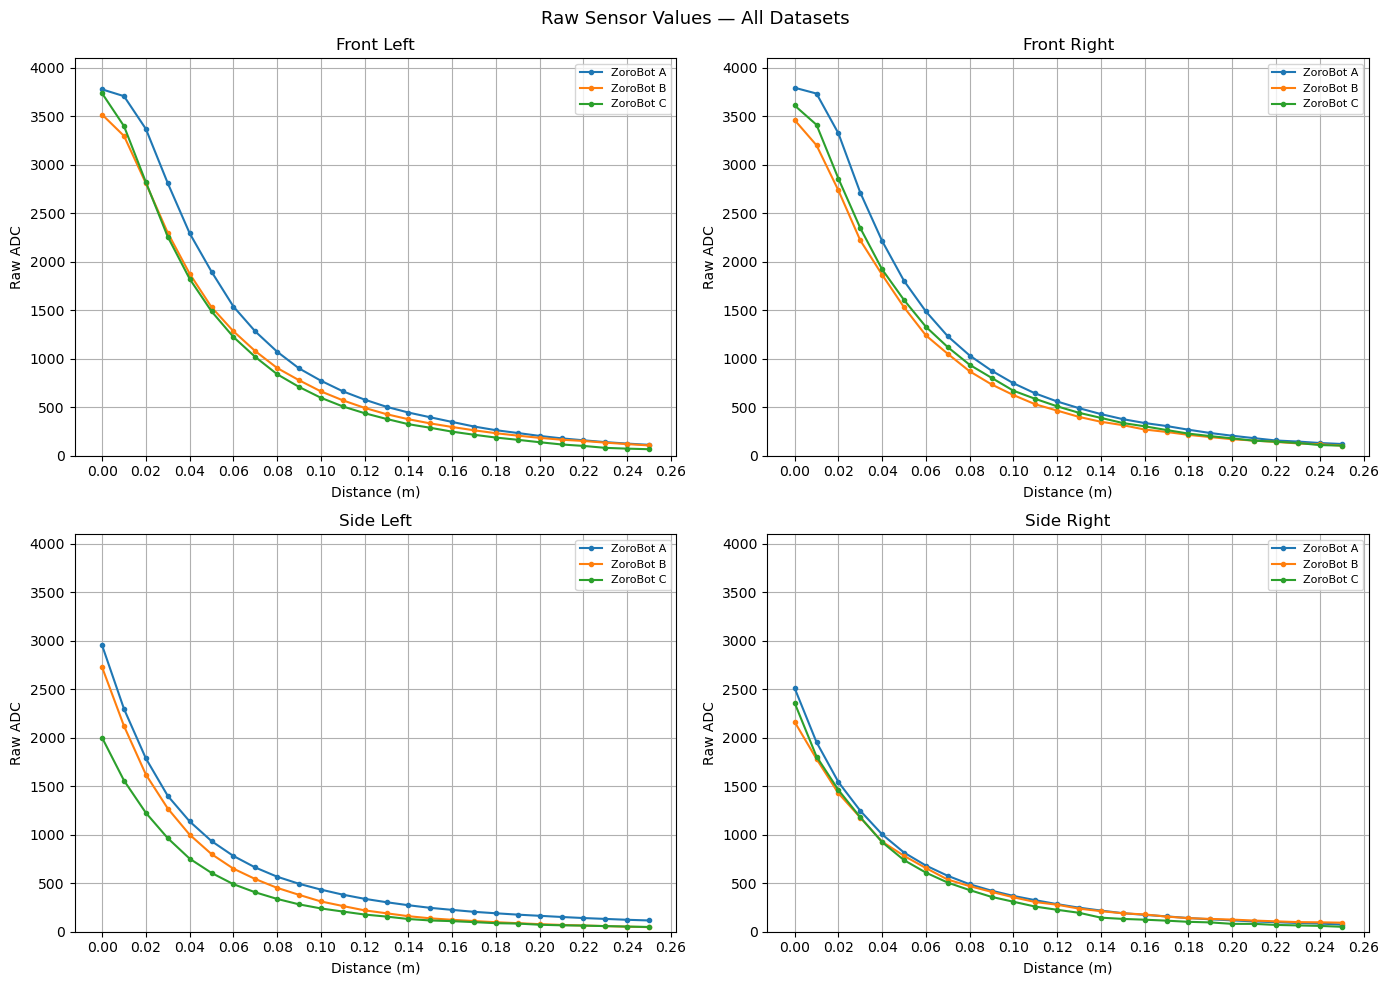

In [3]:
# ===============================
# 2. Visión general — Raw values de todos los datasets
# ===============================

COLORS = plt.cm.tab10.colors  # hasta 10 colores distintos
sensor_names = ['sensor_raw_front_left', 'sensor_raw_front_right',
                'sensor_raw_side_left', 'sensor_raw_side_right']
titles = ['Front Left', 'Front Right', 'Side Left', 'Side Right']
sensor_colors = ['r', 'b', 'g', 'orange']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col, title in zip(axes.flat, sensor_names, titles):
    for i, (label, df) in enumerate(dfs):
        color = COLORS[i % len(COLORS)]
        ax.plot(df['distance'], df[col], 'o-', color=color, markersize=3, label=label)
    ax.set_xlabel('Distance (m)')
    ax.set_ylabel('Raw ADC')
    ax.set_title(title)
    ax.set_ylim(0, 4096)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(0.02))
    ax.legend(fontsize=8)
    ax.grid(True)

fig.suptitle('Raw Sensor Values — All Datasets', fontsize=13)
plt.tight_layout()
plt.show()

In [4]:
# ===============================
# 3. Definición de las funciones de modelo y utilidades
# ===============================

# Modelo teórico (precisión float):
# distance = a / log(raw_sensor_reading) - b
def raw_to_distance(raw, a, b, c):
    return a / np.log(np.maximum(raw + c, 1e-6)) - b

def raw_to_distance_firmware(raw, a, b, c):
    """Modelo que replica la LUT del firmware (step=4).
    
    Simula la división entera por 4 y la lookup table de 1024 entradas
    que usa el firmware en tiempo real (get_ln_value). Útil para verificar
    que los parámetros calculados no introducen errores de cuantificación
    excesivos al ejecutar en el robot.
    """
    ln_index = np.floor((raw + c) / 4).astype(int)
    ln_index = np.clip(ln_index, 0, 1023)
    # ln_index=0 → 1.0 (evita log(0), consistente con get_ln_value del firmware)
    ln_vals = np.where(ln_index == 0, 1.0, np.log(ln_index * 4))
    return a / ln_vals - b

def estimate_p0(raw_vals, dist_vals):
    """Estima p0=[a,b,c] a partir de los extremos de los datos.
    
    Usa los valores raw máximo (distancia más corta) y mínimo (distancia más larga)
    para resolver el sistema:
      d_near = a / ln(r_near) - b
      d_far  = a / ln(r_far)  - b
    
    Returns [a0, b0, 0.0] — c0=0 como punto de partida neutro.
    """
    r_near = raw_vals[-1]   # raw más alto = distancia más corta
    r_far = raw_vals[0]     # raw más bajo = distancia más larga
    d_near = dist_vals[-1]
    d_far = dist_vals[0]
    
    ln_near = np.log(max(r_near, 2))
    ln_far = np.log(max(r_far, 2))
    
    # Resolver: a/ln_far - a/ln_near = d_far - d_near
    a0 = (d_far - d_near) / (1/ln_far - 1/ln_near)
    b0 = a0 / ln_near - d_near
    return [max(a0, 0.1), max(b0, 0.001), 0.0]

def compute_metrics(dist_ref, dist_fit, fitted_mask=None):
    """Calcula R² y RMSE. Si se proporciona fitted_mask, separa por rangos ajustados/excluidos (M5)."""
    ss_res = np.sum((dist_fit - dist_ref) ** 2)
    ss_tot = np.sum((dist_ref - np.mean(dist_ref)) ** 2)
    r_squared = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0.0
    rmse = np.sqrt(np.mean((dist_fit - dist_ref) ** 2))
    
    result = {'R²': r_squared, 'RMSE': rmse}
    
    if fitted_mask is not None:
        rmse_fitted = np.sqrt(np.mean((dist_fit[fitted_mask] - dist_ref[fitted_mask]) ** 2))
        rmse_excluded = np.sqrt(np.mean((dist_fit[~fitted_mask] - dist_ref[~fitted_mask]) ** 2))
        result['RMSE_fitted'] = rmse_fitted
        result['RMSE_excluded'] = rmse_excluded
        result['n_fitted'] = int(np.sum(fitted_mask))
        result['n_excluded'] = int(np.sum(~fitted_mask))
    
    return result

In [5]:
# ===============================
# 4. Selección de rangos de distancia para el ajuste
# ===============================

RANGE_FRONT_1_A = 20 / 1000
RANGE_FRONT_1_B = 70 / 1000
RANGE_FRONT_2_A = 100 / 1000
RANGE_FRONT_2_B = 150 / 1000

RANGE_SIDE_1_A = 5 / 1000
RANGE_SIDE_1_B = 90 / 1000
RANGE_SIDE_2_A = 100 / 1000
RANGE_SIDE_2_B = 170 / 1000

# Crear DataFrames filtrados para cada dataset activo
range_dfs = []  # list of (label, range_df_front, range_df_side)
for label, df in dfs:
    range_front = df[((df['distance'] >= RANGE_FRONT_1_A) & (df['distance'] <= RANGE_FRONT_1_B)) |
                      ((df['distance'] >= RANGE_FRONT_2_A) & (df['distance'] <= RANGE_FRONT_2_B))]
    range_side  = df[((df['distance'] >= RANGE_SIDE_1_A) & (df['distance'] <= RANGE_SIDE_1_B)) |
                      ((df['distance'] >= RANGE_SIDE_2_A) & (df['distance'] <= RANGE_SIDE_2_B))]
    range_dfs.append((label, range_front, range_side))

# Mostrar raw mínimo de cada sensor para cada dataset
print("\nMínimos raw por dataset:")
for label, df in dfs:
    print(f"\n  {label}:")
    print(f"    Front Left:  {df['sensor_raw_front_left'].min():4d}   Front Right: {df['sensor_raw_front_right'].min():4d}")
    print(f"    Side Left:   {df['sensor_raw_side_left'].min():4d}   Side Right:  {df['sensor_raw_side_right'].min():4d}")


Mínimos raw por dataset:

  ZoroBot A:
    Front Left:   112   Front Right:  121
    Side Left:    116   Side Right:    74

  ZoroBot B:
    Front Left:   106   Front Right:  105
    Side Left:     47   Side Right:    93

  ZoroBot C:
    Front Left:    67   Front Right:  104
    Side Left:     49   Side Right:    51


In [6]:
# ===============================
# 5. Ajuste de la curva para cada sensor × dataset
# ===============================

def fit_sensor(name, raw_vals, dist_vals, bounds):
    """Ajusta un sensor y reporta parámetros con incertidumbre y métricas."""
    p0 = estimate_p0(raw_vals, dist_vals)
    
    popt, pcov = curve_fit(raw_to_distance, raw_vals, dist_vals, p0=p0, bounds=bounds)
    perr = np.sqrt(np.maximum(np.diag(pcov), 0))
    
    dist_fit = raw_to_distance(raw_vals, *popt)
    metrics = compute_metrics(dist_vals, dist_fit)
    
    print(f"\n{name}:")
    print(f"  p0 estimado:   a={p0[0]:.4f}, b={p0[1]:.4f}, c={p0[2]:.1f}")
    print(f"  Parámetros:    a = {popt[0]:.4f} ± {perr[0]:.4f}")
    print(f"                 b = {popt[1]:.4f} ± {perr[1]:.4f}")
    print(f"                 c = {popt[2]:.2f} ± {perr[2]:.2f}")
    print(f"  Bondad ajuste: R² = {metrics['R²']:.4f},  RMSE = {metrics['RMSE']*1000:.2f} mm")
    
    return popt

# ── Ajustar todos los sensores de todos los datasets ──
results = {}  # (label, sensor_key) -> (a, b, c)

for label, range_front, range_side in range_dfs:
    print(f"\n{'='*60}")
    print(f"  {label}")
    print(f"{'='*60}")
    
    # Frontales
    results[(label, 'front_left')] = fit_sensor(
        f"[{label}] Front Left",
        range_front['sensor_raw_front_left'].values,
        range_front['distance'].values,
        bounds=([-10, -1, -200], [10, 1, 200]))
    
    results[(label, 'front_right')] = fit_sensor(
        f"[{label}] Front Right",
        range_front['sensor_raw_front_right'].values,
        range_front['distance'].values,
        bounds=([-10, -1, -200], [10, 1, 200]))
    
    # Laterales
    results[(label, 'side_left')] = fit_sensor(
        f"[{label}] Side Left",
        range_side['sensor_raw_side_left'].values,
        range_side['distance'].values,
        bounds=([-5, -2, -300], [5, 2, 300]))
    
    results[(label, 'side_right')] = fit_sensor(
        f"[{label}] Side Right",
        range_side['sensor_raw_side_right'].values,
        range_side['distance'].values,
        bounds=([-5, -2, -300], [5, 2, 300]))



  ZoroBot A

[ZoroBot A] Front Left:
  p0 estimado:   a=2.9503, b=0.3432, c=0.0
  Parámetros:    a = 2.8812 ± 0.0678
                 b = 0.3331 ± 0.0086
                 c = -3.31 ± 15.80
  Bondad ajuste: R² = 0.9997,  RMSE = 0.74 mm

[ZoroBot A] Front Right:
  p0 estimado:   a=2.8733, b=0.3343, c=0.0
  Parámetros:    a = 2.8657 ± 0.0340
                 b = 0.3326 ± 0.0043
                 c = 2.25 ± 7.73
  Bondad ajuste: R² = 0.9999,  RMSE = 0.38 mm

[ZoroBot A] Side Left:
  p0 estimado:   a=2.7282, b=0.3425, c=0.0
  Parámetros:    a = 2.3567 ± 0.0265
                 b = 0.2966 ± 0.0037
                 c = -50.43 ± 3.14
  Bondad ajuste: R² = 0.9998,  RMSE = 0.66 mm

[ZoroBot A] Side Right:
  p0 estimado:   a=2.4405, b=0.3121, c=0.0
  Parámetros:    a = 2.3987 ± 0.0340
                 b = 0.3072 ± 0.0049
                 c = -4.69 ± 3.78
  Bondad ajuste: R² = 0.9997,  RMSE = 0.80 mm

  ZoroBot B

[ZoroBot B] Front Left:
  p0 estimado:   a=2.8120, b=0.3341, c=0.0
  Parámetros:    

In [7]:
# ===============================
# 6. Análisis de error para todos los datasets
# ===============================

sensor_keys = [
    ('front_left',  'sensor_raw_front_left',  'Front Left'),
    ('front_right', 'sensor_raw_front_right', 'Front Right'),
    ('side_left',   'sensor_raw_side_left',   'Side Left'),
    ('side_right',  'sensor_raw_side_right',  'Side Right'),
]

# ── Calcular distancias ajustadas para cada dataset ──
for label, df in dfs:
    for key, raw_col, _ in sensor_keys:
        a, b, c = results[(label, key)]
        df[f'distance_fit_{key}'] = raw_to_distance(df[raw_col].values, a, b, c)
        df[f'error_{key}'] = df[f'distance_fit_{key}'] - df['distance']

# ── Estadísticas y métricas por dataset ──
for label, df in dfs:
    print(f"\n{'='*60}")
    print(f"  {label}")
    print(f"{'='*60}")
    
    for key, raw_col, name in sensor_keys:
        print(f"\n--- {name} ---")
        print(df[f'error_{key}'].describe())
    
    # M5: RMSE por rangos
    print(f"\n  === RMSE por rangos (M5) ===")
    front_mask = ((df['distance'] >= RANGE_FRONT_1_A) & (df['distance'] <= RANGE_FRONT_1_B)) | \
                  ((df['distance'] >= RANGE_FRONT_2_A) & (df['distance'] <= RANGE_FRONT_2_B))
    side_mask  = ((df['distance'] >= RANGE_SIDE_1_A) & (df['distance'] <= RANGE_SIDE_1_B)) | \
                  ((df['distance'] >= RANGE_SIDE_2_A) & (df['distance'] <= RANGE_SIDE_2_B))
    
    metrics_list = [
        ("Front Left",  df['distance'].values, df['distance_fit_front_left'].values, front_mask),
        ("Front Right", df['distance'].values, df['distance_fit_front_right'].values, front_mask),
        ("Side Left",   df['distance'].values, df['distance_fit_side_left'].values, side_mask),
        ("Side Right",  df['distance'].values, df['distance_fit_side_right'].values, side_mask),
    ]
    for mname, d_ref, d_fit, mask in metrics_list:
        m = compute_metrics(d_ref, d_fit, mask)
        print(f"  {mname}:")
        print(f"    Todos (n={m['n_fitted']+m['n_excluded']}): R²={m['R²']:.4f}, RMSE={m['RMSE']*1000:.2f} mm")
        print(f"    Ajustados (n={m['n_fitted']}):  RMSE={m['RMSE_fitted']*1000:.2f} mm")
        print(f"    Excluidos (n={m['n_excluded']}): RMSE={m['RMSE_excluded']*1000:.2f} mm")
    
    # P7: Error de cuantificación LUT
    print(f"\n  === Error cuantificación LUT (P7) ===")
    for key, raw_col, name in sensor_keys:
        a, b, c = results[(label, key)]
        raw_vals = df[raw_col].values
        d_float = raw_to_distance(raw_vals, a, b, c)
        d_fw    = raw_to_distance_firmware(raw_vals, a, b, c)
        q_error = np.abs(d_float - d_fw)
        print(f"  {name}: máx={np.max(q_error)*1000:.2f} mm,  RMSE={np.sqrt(np.mean(q_error**2))*1000:.2f} mm")


  ZoroBot A

--- Front Left ---
count    26.000000
mean      0.006267
std       0.009506
min      -0.001288
25%      -0.000020
50%       0.000660
75%       0.009650
max       0.031430
Name: error_front_left, dtype: float64

--- Front Right ---
count    26.000000
mean      0.003071
std       0.005333
min      -0.002529
25%      -0.000267
50%       0.000182
75%       0.005412
max       0.015142
Name: error_front_right, dtype: float64

--- Side Left ---
count    26.000000
mean      0.001959
std       0.004496
min      -0.001193
25%      -0.000524
50%       0.000562
75%       0.001017
max       0.016784
Name: error_side_left, dtype: float64

--- Side Right ---
count    26.000000
mean      0.000705
std       0.001920
min      -0.001406
25%      -0.000497
50%       0.000472
75%       0.000998
max       0.008746
Name: error_side_right, dtype: float64

  === RMSE por rangos (M5) ===
  Front Left:
    Todos (n=26): R²=0.9776, RMSE=11.23 mm
    Ajustados (n=12):  RMSE=0.74 mm
    Excluidos (n=1

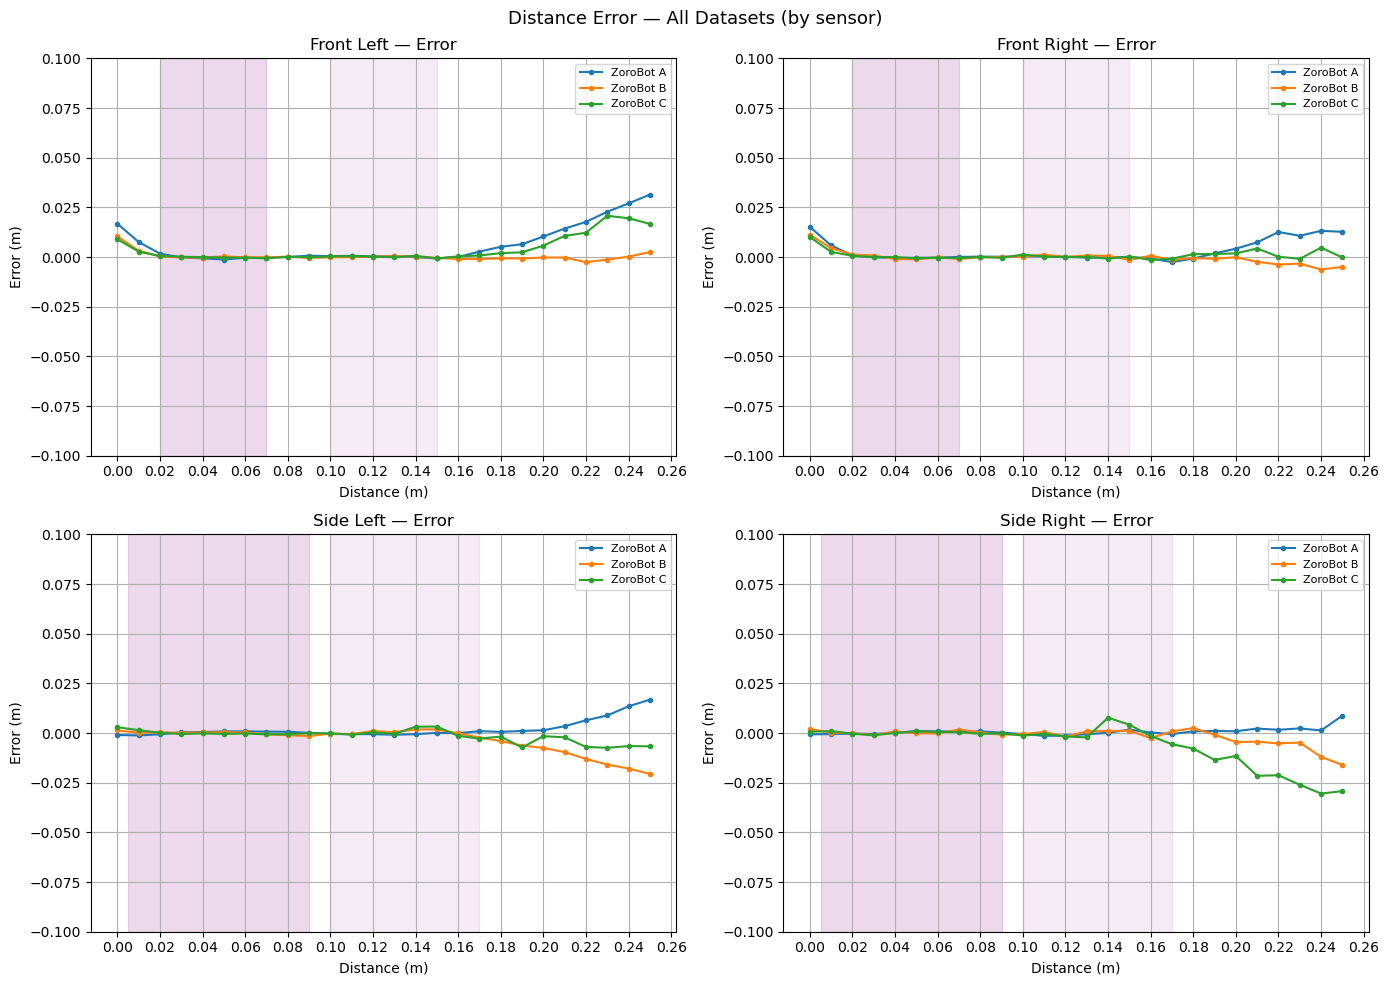

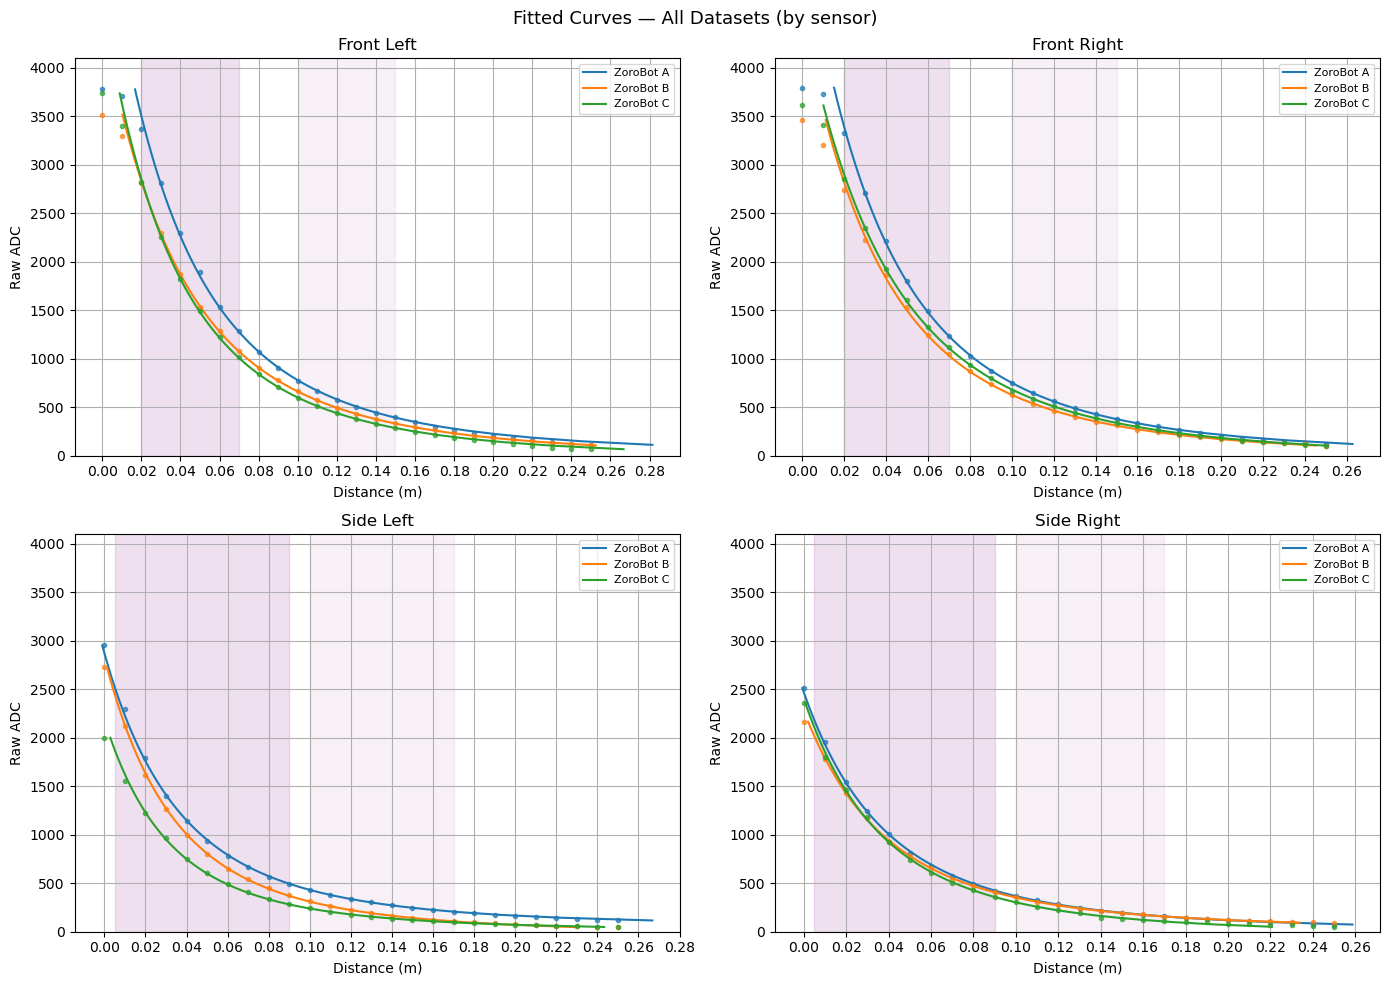

In [8]:
# ===============================
# 7. Gráficas de error y curvas ajustadas
# ===============================

# ── Gráficas de error ──
if PLOT_MODE == "by_sensor":
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    for ax, (key, raw_col, title) in zip(axes.flat, sensor_keys):
        for i, (label, df) in enumerate(dfs):
            color = COLORS[i % len(COLORS)]
            ax.plot(df['distance'], df[f'error_{key}'], 'o-', color=color,
                    markersize=3, label=label)
        if 'front' in key:
            ax.axvspan(RANGE_FRONT_1_A, RANGE_FRONT_1_B, color='purple', alpha=0.15)
            ax.axvspan(RANGE_FRONT_2_A, RANGE_FRONT_2_B, color='purple', alpha=0.08)
        else:
            ax.axvspan(RANGE_SIDE_1_A, RANGE_SIDE_1_B, color='purple', alpha=0.15)
            ax.axvspan(RANGE_SIDE_2_A, RANGE_SIDE_2_B, color='purple', alpha=0.08)
        ax.set_xlabel('Distance (m)')
        ax.set_ylabel('Error (m)')
        ax.set_title(f'{title} — Error')
        ax.set_ylim(-0.1, 0.1)
        ax.xaxis.set_major_locator(ticker.MultipleLocator(0.02))
        ax.legend(fontsize=8)
        ax.grid(True)
    fig.suptitle('Distance Error — All Datasets (by sensor)', fontsize=13)
    plt.tight_layout()
    plt.show()

else:
    for label, df in dfs:
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        for ax, (key, raw_col, title) in zip(axes.flat, sensor_keys):
            ax.plot(df['distance'], df[f'error_{key}'], 'o-',
                    color=sensor_colors[sensor_keys.index((key, raw_col, title))],
                    markersize=3)
            if 'front' in key:
                ax.axvspan(RANGE_FRONT_1_A, RANGE_FRONT_1_B, color='purple', alpha=0.15)
                ax.axvspan(RANGE_FRONT_2_A, RANGE_FRONT_2_B, color='purple', alpha=0.08)
            else:
                ax.axvspan(RANGE_SIDE_1_A, RANGE_SIDE_1_B, color='purple', alpha=0.15)
                ax.axvspan(RANGE_SIDE_2_A, RANGE_SIDE_2_B, color='purple', alpha=0.08)
            ax.set_xlabel('Distance (m)')
            ax.set_ylabel('Error (m)')
            ax.set_title(title)
            ax.set_ylim(-0.1, 0.1)
            ax.xaxis.set_major_locator(ticker.MultipleLocator(0.02))
            ax.grid(True)
        fig.suptitle(f'Distance Error — {label}', fontsize=13)
        plt.tight_layout()
        plt.show()

# ── Gráficas de curvas ajustadas ──
if PLOT_MODE == "by_sensor":
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    for ax, (key, raw_col, title) in zip(axes.flat, sensor_keys):
        for i, (label, df) in enumerate(dfs):
            color = COLORS[i % len(COLORS)]
            a, b, c = results[(label, key)]
            ax.plot(df['distance'], df[raw_col], 'o', color=color, markersize=3, alpha=0.7)
            raw_range = np.linspace(df[raw_col].min(), df[raw_col].max(), 100)
            ax.plot(raw_to_distance(raw_range, a, b, c), raw_range, '-', color=color, linewidth=1.5, label=label)
        if 'front' in key:
            ax.axvspan(RANGE_FRONT_1_A, RANGE_FRONT_1_B, color='purple', alpha=0.12)
            ax.axvspan(RANGE_FRONT_2_A, RANGE_FRONT_2_B, color='purple', alpha=0.06)
        else:
            ax.axvspan(RANGE_SIDE_1_A, RANGE_SIDE_1_B, color='purple', alpha=0.12)
            ax.axvspan(RANGE_SIDE_2_A, RANGE_SIDE_2_B, color='purple', alpha=0.06)
        ax.set_xlabel('Distance (m)')
        ax.set_ylabel('Raw ADC')
        ax.set_title(title)
        ax.set_ylim(0, 4096)
        ax.xaxis.set_major_locator(ticker.MultipleLocator(0.02))
        ax.legend(fontsize=8)
        ax.grid(True)
    fig.suptitle('Fitted Curves — All Datasets (by sensor)', fontsize=13)
    plt.tight_layout()
    plt.show()

else:
    for label, df in dfs:
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        for ax, (key, raw_col, title) in zip(axes.flat, sensor_keys):
            a, b, c = results[(label, key)]
            raw_range = np.linspace(df[raw_col].min(), df[raw_col].max(), 100)
            ax.plot(df['distance'], df[raw_col], 'o', markersize=3,
                    color=sensor_colors[sensor_keys.index((key, raw_col, title))])
            ax.plot(raw_to_distance(raw_range, a, b, c), raw_range, '-',
                    color=sensor_colors[sensor_keys.index((key, raw_col, title))], linewidth=1.5)
            if 'front' in key:
                ax.axvspan(RANGE_FRONT_1_A, RANGE_FRONT_1_B, color='purple', alpha=0.12)
                ax.axvspan(RANGE_FRONT_2_A, RANGE_FRONT_2_B, color='purple', alpha=0.06)
            else:
                ax.axvspan(RANGE_SIDE_1_A, RANGE_SIDE_1_B, color='purple', alpha=0.12)
                ax.axvspan(RANGE_SIDE_2_A, RANGE_SIDE_2_B, color='purple', alpha=0.06)
            ax.set_xlabel('Distance (m)')
            ax.set_ylabel('Raw ADC')
            ax.set_title(title)
            ax.set_ylim(0, 4096)
            ax.xaxis.set_major_locator(ticker.MultipleLocator(0.02))
            ax.grid(True)
        fig.suptitle(f'Fitted Curves — {label}', fontsize=13)
        plt.tight_layout()
        plt.show()


In [9]:
# ===============================
# 8. Structs C para copiar al firmware
# ===============================

print("╔" + "═" * 58 + "╗")
print("║  STRUCTS C PARA EL FIRMWARE  —  copiar en sensors.c      ║")
print("╚" + "═" * 58 + "╝")

for label, _, _ in range_dfs:
    fl = results[(label, 'front_left')]
    fr = results[(label, 'front_right')]
    sl = results[(label, 'side_left')]
    sr = results[(label, 'side_right')]
    
    print(f"\n/* ── {label} ── */")
    print("struct sensors_distance_calibration sensors_distance_calibrations[] = {")
    print("\t[SENSOR_FRONT_LEFT_WALL_ID] = {")
    print(f"\t\t.a = {fl[0]:.3f},")
    print(f"\t\t.b = {fl[1]:.3f},")
    print(f"\t\t.c = {fl[2]:.3f},")
    print("\t},")
    print("\t[SENSOR_FRONT_RIGHT_WALL_ID] = {")
    print(f"\t\t.a = {fr[0]:.3f},")
    print(f"\t\t.b = {fr[1]:.3f},")
    print(f"\t\t.c = {fr[2]:.3f},")
    print("\t},")
    print("\t[SENSOR_SIDE_LEFT_WALL_ID] = {")
    print(f"\t\t.a = {sl[0]:.3f},")
    print(f"\t\t.b = {sl[1]:.3f},")
    print(f"\t\t.c = {sl[2]:.3f},")
    print("\t},")
    print("\t[SENSOR_SIDE_RIGHT_WALL_ID] = {")
    print(f"\t\t.a = {sr[0]:.3f},")
    print(f"\t\t.b = {sr[1]:.3f},")
    print(f"\t\t.c = {sr[2]:.3f},")
    print("\t},")
    print("};")


╔══════════════════════════════════════════════════════════╗
║  STRUCTS C PARA EL FIRMWARE  —  copiar en sensors.c      ║
╚══════════════════════════════════════════════════════════╝

/* ── ZoroBot A ── */
struct sensors_distance_calibration sensors_distance_calibrations[] = {
	[SENSOR_FRONT_LEFT_WALL_ID] = {
		.a = 2.881,
		.b = 0.333,
		.c = -3.311,
	},
	[SENSOR_FRONT_RIGHT_WALL_ID] = {
		.a = 2.866,
		.b = 0.333,
		.c = 2.250,
	},
	[SENSOR_SIDE_LEFT_WALL_ID] = {
		.a = 2.357,
		.b = 0.297,
		.c = -50.430,
	},
	[SENSOR_SIDE_RIGHT_WALL_ID] = {
		.a = 2.399,
		.b = 0.307,
		.c = -4.694,
	},
};

/* ── ZoroBot B ── */
struct sensors_distance_calibration sensors_distance_calibrations[] = {
	[SENSOR_FRONT_LEFT_WALL_ID] = {
		.a = 2.915,
		.b = 0.346,
		.c = 23.994,
	},
	[SENSOR_FRONT_RIGHT_WALL_ID] = {
		.a = 2.795,
		.b = 0.332,
		.c = 22.453,
	},
	[SENSOR_SIDE_LEFT_WALL_ID] = {
		.a = 2.175,
		.b = 0.273,
		.c = 28.662,
	},
	[SENSOR_SIDE_RIGHT_WALL_ID] = {
		.a = 2.374,
		.b = 0.307,
		.